## Flanking versus breaching

**Definitions** (Nichols et al., 2023): Flanking = lateral scour around the berm end; breaching = perpendicular break through the berm.

**Literature context:** Flanking was more common than breaching overall. Coarser soils skew toward flanking; finer soils have a higher breach share. Where breaches occurred on coarser-textured soils, up- and downslope differences in grass cover diminished.

**Mechanistic interpretation:** Sandy/loamy sand has low cohesion → water routes around the berm end and incises a scour pathway → more flanking. Clay loam resists end-scour → water ponds and overtops → more breaching. (Nichols et al. do not discuss this mechanism; their discussion centers on moisture-holding capacity and vegetation response.)

> Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005

### Summary of results

**Strongest predictors of breach vs. flank (among failed berms)**

| Predictor | χ² | p | Cramér's V |
|---|---|---|---|
| Berm length | 46.8 | 6.8e-11 | 0.246 |
| Texture (top 3) | 30.8 | 3.3e-06 | 0.156 |
| High Clay | 18.5 | 9.7e-05 | 0.154 |
| Slope | 13.8 | 0.0010 | 0.133 |
| Soil Development | 13.8 | 0.0010 | 0.133 |
| Landform | 14.4 | 0.0061 | 0.096 |

Log flow accumulation (KW H = 42.9, p = 4.9e-10) and berm angle (KW H = 29.0, p = 5.1e-07) are the strongest continuous predictors. SAVI indices were non-significant (all p > 0.38).

**Key conditional probabilities (among failed berms)**

- Sandy loam → 75% flank / 25% breach; Clay loam → 51% flank / 49% breach
- Fan terraces → 75% flank / 25% breach; Flood plains → 56% flank / 44% breach
- Steep slopes → 71% flank; Shallow slopes → 55% flank
- B-horizon soils → 74% flank; No B horizon → 57% flank

**Interpretation:** Breaching is associated with longer berms, finer-textured soils, higher flow accumulation, shallower slopes, and flood-plain settings — consistent with concentrated overtopping. Flanking is associated with shorter berms, sandy soils, steep slopes, fan terraces, and B-horizon soils — consistent with end-run failures.

In [34]:
import pandas as pd
import glob
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

# Global display preferences (apply notebook-wide)
from IPython.display import display, HTML
pd.set_option("display.max_columns", 50)


In [35]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
    FS, FS_SUP,
)
from plotting import (
    width, add_bar_edges,
    _sig_stars, _fisher_one_sided,
    _two_cat_metrics, _draw_two_cat_panel, _draw_multi_cat_panel,
)
from analysis import chi2_with_cramers_v, _bh_adjust
from registry import register_failure_mechanisms_figure

In [36]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'profile_de

In [37]:
# Where does this term come from?
data['berm_angle']

0     -72.029343
1     -41.091470
2      79.006820
3     -74.491529
4      -3.966655
         ...    
770   -61.471091
771   -14.077517
772     4.514847
773    16.896728
774     8.200288
Name: berm_angle, Length: 775, dtype: float64

In [38]:
# ── Additional shared-module imports ──────────────────────────────────────────
from analysis import chi2_with_cramers_v, _bh_adjust
from registry import register_failure_mechanisms_figure
from itertools import combinations as _combinations
from scipy.stats import kruskal as _kruskal, mannwhitneyu as _mannwhitneyu

import os as _os

# ── Data preparation ─────────────────────────────────────────────────────────
df = data.copy()

# Fill missing Fail_Type with "Intact"; drop ambiguous "Breach and Flank"
df['Fail_Type'] = df['Fail_Type'].fillna("Intact")
df = df.loc[df['Fail_Type'] != 'Breach and Flank'].copy()

_fig_dir = _os.path.join('..', 'figures', 'failure_mechanisms')
_os.makedirs(_fig_dir, exist_ok=True)

print(f"Working df: {len(df):,} rows")
print(f"\nFail_Type value counts:")
print(df['Fail_Type'].value_counts().to_string())
print(f"\nOverall proportions:")
print((df['Fail_Type'].value_counts(normalize=True) * 100).round(1).to_string())

# ── Top-3 soil textures by count ─────────────────────────────────────────────
_top3_tex = df['Texture'].value_counts().head(3).index.tolist()
print(f"\nTop 3 textures: {_top3_tex}")

# ── Helper: grouped bar chart for 3-level Fail_Type ─────────────────────────
def _plot_fail_bars(ax, ct, group_order, title, chi2_p=None):
    """Grouped bar chart showing Fail_Type proportions (Intact / Breach / Flank)
    for each level of *group_order*."""
    _pct = ct.div(ct.sum(axis=1), axis=0)
    _x = np.arange(len(group_order))
    _w = 0.25
    for i, ft in enumerate(fail_order):
        vals = [_pct.loc[g, ft] if g in _pct.index else 0 for g in group_order]
        ax.bar(_x + i * _w, vals, _w, label=ft,
               color=fail_colors[ft], edgecolor='black', linewidth=0.6)
    ax.set_xticks(_x + _w)
    ax.set_xticklabels(group_order, rotation=0, ha='center')
    ax.set_ylabel('Proportion')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    _sub = f'\n(p = {chi2_p:.3g})' if chi2_p is not None else ''
    ax.set_title(f'{title}{_sub}')
    ax.legend(frameon=False)

# ── Helper: pairwise chi-square on 2×3 Fail_Type sub-tables ─────────────────
def _pairwise_chi2_3cat(ct, alpha=0.05):
    """Pairwise chi-square between all row pairs of a groups × Fail_Type table.
    Returns DataFrame with FDR-corrected q-values."""
    groups = list(ct.index)
    rows = []
    for a, b in _combinations(groups, 2):
        sub = ct.loc[[a, b]]
        chi2, p, dof, _ = chi2_contingency(sub)
        rows.append({'group_a': a, 'group_b': b, 'chi2': chi2, 'dof': dof, 'p_raw': p})
    _df = pd.DataFrame(rows)
    if len(_df):
        _df['q_fdr'] = _bh_adjust(_df['p_raw'].values)
        _df['significant'] = _df['q_fdr'] < alpha
    return _df

# ── Helper: Kruskal-Wallis + pairwise Mann-Whitney for continuous × Fail_Type ─
def _continuous_by_failtype(df_sub, col, label=None):
    """Kruskal-Wallis across Fail_Type groups + pairwise Mann-Whitney with FDR."""
    label = label or col
    groups = {ft: df_sub.loc[df_sub['Fail_Type'] == ft, col].dropna()
              for ft in fail_order}
    arrays = [groups[ft] for ft in fail_order if len(groups[ft]) > 0]
    if len(arrays) < 2:
        print(f'  {label}: fewer than 2 non-empty groups')
        return None
    _H, _p_kw = _kruskal(*arrays)
    print(f'Kruskal-Wallis  H = {_H:.2f},  p = {_p_kw:.3g}')
    print(f'  Group medians:')
    for ft in fail_order:
        g = groups[ft]
        if len(g):
            print(f'    {ft:8s}: median = {g.median():.3f}  (n = {len(g)})')

    rows = []
    for a, b in _combinations(fail_order, 2):
        if len(groups[a]) == 0 or len(groups[b]) == 0:
            continue
        _U, _p = _mannwhitneyu(groups[a], groups[b], alternative='two-sided')
        rows.append({'group_a': a, 'group_b': b, 'U': _U, 'p_raw': _p})
    pw = pd.DataFrame(rows)
    if len(pw):
        pw['q_fdr'] = _bh_adjust(pw['p_raw'].values)
        pw['significant'] = pw['q_fdr'] < 0.05
    print(f'\nPairwise Mann-Whitney (FDR q < 0.05):')
    _sig = pw[pw['significant']] if len(pw) else pw
    if len(_sig):
        display(_sig.round(4).reset_index(drop=True))
    else:
        print('  (none)')
    return {'H': _H, 'p_kw': _p_kw, 'pairwise': pw, 'groups': groups}

# ── Helper: box + strip plot for continuous × Fail_Type ──────────────────────
def _plot_continuous_by_failtype(ax, df_sub, col, title, ylabel=None):
    """Box + strip plot of *col* by Fail_Type with fail_colors."""
    _palette = {ft: fail_colors[ft] for ft in fail_order}
    sns.boxplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
                palette=_palette, showfliers=False, ax=ax,
                boxprops=dict(edgecolor='black'), medianprops=dict(color='black'))
    sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
                  palette=_palette, size=3, alpha=0.35, jitter=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    if ylabel:
        ax.set_ylabel(ylabel)


Working df: 775 rows

Fail_Type value counts:
Fail_Type
Intact    458
Flank     203
Breach    114

Overall proportions:
Fail_Type
Intact    59.1
Flank     26.2
Breach    14.7

Top 3 textures: ['Clay loam', 'Sandy loam', 'Silt loam']


In [39]:
# ── Overall Fail_Type distribution by Landform ────────────────────────────────
print("=== Fail_Type counts by Landform ===")
_ct_lf = pd.crosstab(df['Landform'], df['Fail_Type'])[fail_order]
display(_ct_lf)

print("\n=== Within-landform proportions (%) ===")
_ct_lf_pct = (_ct_lf.div(_ct_lf.sum(axis=1), axis=0) * 100).round(1)
display(_ct_lf_pct)

print(f"\nTotal failed (Breach + Flank): "
      f"{(df['Fail_Type'] != 'Intact').sum()} / {len(df)} "
      f"= {(df['Fail_Type'] != 'Intact').mean():.1%}")
      

=== Fail_Type counts by Landform ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,153,31,92
Flood plains,215,64,80
Stream terraces,90,19,31



=== Within-landform proportions (%) ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,55.4,11.2,33.3
Flood plains,59.9,17.8,22.3
Stream terraces,64.3,13.6,22.1



Total failed (Breach + Flank): 317 / 775 = 40.9%


## Breaches and flanks separately

In [40]:
# ── Soil texture × Failure type: probability table + pairwise Fisher tests ───

# Top 3 textures by count, ordered fine → coarse via texture_order
_tex_counts = df['Texture'].value_counts()
_top3 = [t for t in texture_order if t in _tex_counts.nlargest(3).index]
_tex_colors_top3 = {t: TEXTURE_COLORS[t] for t in _top3}

_df_tex = df[df['Texture'].isin(_top3)].copy()
_df_tex['failed'] = _df_tex['Fail_Type'].ne('Intact')

_n_tex = {t: (_df_tex['Texture'] == t).sum() for t in _top3}

# Overall chi-square for Texture × Fail_Type
_ct_tex = pd.crosstab(_df_tex['Texture'], _df_tex['Fail_Type'])
_ct_tex = _ct_tex.reindex(columns=fail_order, fill_value=0).reindex(_top3)
_chi2_tex, _p_tex, _dof_tex, _V_tex, _ = chi2_with_cramers_v(_ct_tex)
_p_str_tex = f'p = {_p_tex:.3g}' if _p_tex >= 0.001 else 'p < 0.001'

# Unconditional metrics
_rows_tx = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_tex)
    _row = {}
    for _t in _top3:
        _c = _mask[_df_tex['Texture'] == _t].sum()
        _row[_t] = _c / _n_tex[_t]
    for _ci, _cj in _combinations(range(len(_top3)), 2):
        _ta, _tb = _top3[_ci], _top3[_cj]
        _ca = _mask[_df_tex['Texture'] == _ta].sum()
        _cb = _mask[_df_tex['Texture'] == _tb].sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_tex[_ta], _cb, _n_tex[_tb])
        _row[f'{_ta[:2]}v{_tb[:2]} p'] = _p_val
        _row[f'{_ta[:2]}v{_tb[:2]} sig'] = _sig_stars(_p_val)
    _rows_tx[_metric] = _row

# Conditional metrics (among failed only)
_df_txf = _df_tex[_df_tex['failed']]
_n_tex_f = {t: (_df_txf['Texture'] == t).sum() for t in _top3}
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _row = {}
    for _t in _top3:
        _c = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _t)).sum()
        _row[_t] = _c / _n_tex_f[_t] if _n_tex_f[_t] > 0 else float('nan')
    for _ci, _cj in _combinations(range(len(_top3)), 2):
        _ta, _tb = _top3[_ci], _top3[_cj]
        _ca = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _ta)).sum()
        _cb = ((_df_txf['Fail_Type'] == _ft) & (_df_txf['Texture'] == _tb)).sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_tex_f[_ta], _cb, _n_tex_f[_tb])
        _row[f'{_ta[:2]}v{_tb[:2]} p'] = _p_val
        _row[f'{_ta[:2]}v{_tb[:2]} sig'] = _sig_stars(_p_val)
    _rows_tx[_metric] = _row

tex_metrics = pd.DataFrame(_rows_tx).T

print(f"Texture \u00d7 Fail_Type  \u03c7\u00b2 = {_chi2_tex:.2f}, {_p_str_tex}, Cram\u00e9r's V = {_V_tex:.2f}")
print(f"Textures (fine \u2192 coarse): {_top3}")
print(f"n per texture: { {t: _n_tex[t] for t in _top3} }")
print()

_disp = tex_metrics.copy()
for _t in _top3:
    _disp[_t] = (_disp[_t].astype(float) * 100).round(1)
_sig_cols = [c for c in _disp.columns if c.endswith(' sig')]
display(_disp[_top3 + _sig_cols])

Texture × Fail_Type  χ² = 30.82, p < 0.001, Cramér's V = 0.16
Textures (fine → coarse): ['Clay loam', 'Silt loam', 'Sandy loam']
n per texture: {'Clay loam': 283, 'Silt loam': 137, 'Sandy loam': 210}



,Clay loam,Silt loam,Sandy loam,ClvSi sig,ClvSa sig,SivSa sig
Intact,61.8,64.2,46.2,ns,***,***
Any failure,38.2,35.8,53.8,ns,***,***
Breach,18.7,13.9,13.3,ns,ns,ns
Flank,19.4,21.9,40.5,ns,***,***
Vegetation response,39.2,54.0,60.0,**,***,ns
Breach | failed,49.1,38.8,24.8,ns,***,ns
Flank | failed,50.9,61.2,75.2,ns,***,ns


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 3)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


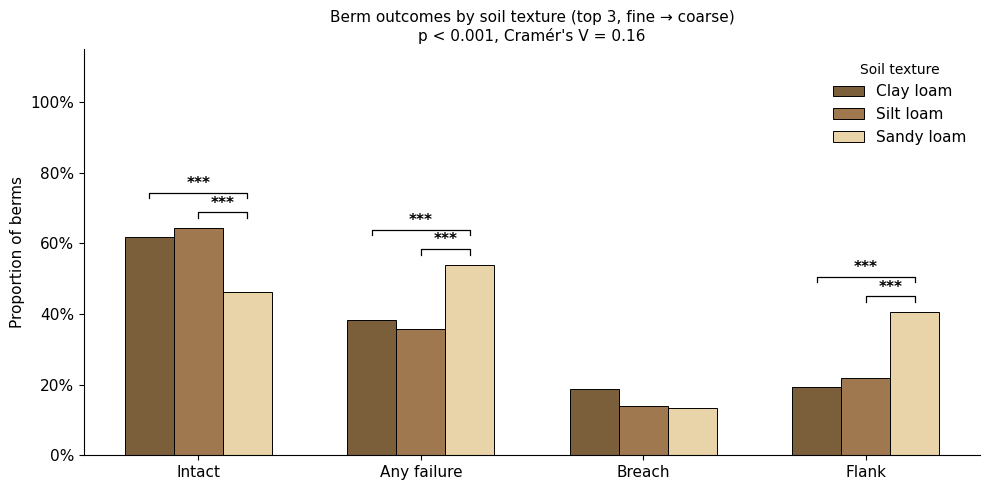

Saved: fig3_texture_fail_type.png


In [41]:
# ── Soil texture × Failure type figure: grouped bars with brackets ────────────
_FS = FS

_plot_metrics_tx = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(10, 5))

_n_tex_bars = len(_top3)
_w = 0.22
_offsets = np.linspace(-(_n_tex_bars - 1) * _w / 2,
                       (_n_tex_bars - 1) * _w / 2, _n_tex_bars)
_x = np.arange(len(_plot_metrics_tx))

for _ti, _tex in enumerate(_top3):
    _vals = [tex_metrics.loc[m, _tex] for m in _plot_metrics_tx]
    ax.bar(_x + _offsets[_ti], _vals, _w, label=_tex,
           color=_tex_colors_top3[_tex], edgecolor='black', linewidth=0.7)

# Pairwise significance brackets per metric
_bh = 0.015
for _mi, _metric in enumerate(_plot_metrics_tx):
    _pairs = list(_combinations(range(_n_tex_bars), 2))
    _pairs.sort(key=lambda p: abs(_offsets[p[1]] - _offsets[p[0]]))
    _current_top = max(tex_metrics.loc[_metric, _tex] for _tex in _top3) + 0.03
    for _ci, _cj in _pairs:
        _ta, _tb = _top3[_ci], _top3[_cj]
        _sig_key = f'{_ta[:2]}v{_tb[:2]} sig'
        _stars = tex_metrics.loc[_metric, _sig_key]
        if _stars == 'ns':
            continue
        _x_a = _mi + _offsets[_ci]
        _x_b = _mi + _offsets[_cj]
        _y_a = tex_metrics.loc[_metric, _ta]
        _y_b = tex_metrics.loc[_metric, _tb]
        _yb = max(max(_y_a, _y_b) + 0.02, _current_top)
        ax.plot([_x_a, _x_a, _x_b, _x_b],
                [_yb, _yb + _bh, _yb + _bh, _yb], lw=0.9, color='black')
        ax.text((_x_a + _x_b) / 2, _yb + _bh + 0.005, _stars,
                ha='center', va='bottom', fontsize=_FS,
                fontweight='bold', color='black')
        _current_top = _yb + _bh + 0.04

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_tx, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f"Berm outcomes by soil texture (top 3, fine \u2192 coarse)\n"
             f"{_p_str_tex}, Cram\u00e9r's V = {_V_tex:.2f}", fontsize=_FS)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Soil texture', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig3_texture_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig3', _fname,
    f'Grouped comparison of berm outcome proportions across top 3 soil textures '
    f'({", ".join(_top3)}, fine \u2192 coarse) with pairwise one-sided Fisher exact '
    f'significance brackets. \u03c7\u00b2 = {_chi2_tex:.2f}, {_p_str_tex}, '
    f"Cram\u00e9r's V = {_V_tex:.2f}.",
    f'Outcome proportions compared by soil texture. Finer textures show higher '
    f'breach share; coarser textures skew toward flanking.',
)
plt.show()
print(f'Saved: {_fname}')

### Landform × Failure type

Pairwise one-sided Fisher exact tests compare landform classes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [42]:
# ── Landform × Failure type: probability table + pairwise Fisher tests ────────

_df_lf = df.dropna(subset=['Landform']).copy()
_df_lf['failed'] = _df_lf['Fail_Type'].ne('Intact')

_n_lf = {lf: (_df_lf['Landform'] == lf).sum() for lf in lf_order}

# Overall chi-square for Landform × Fail_Type
_ct_lf2 = pd.crosstab(_df_lf['Landform'], _df_lf['Fail_Type'])
_ct_lf2 = _ct_lf2.reindex(columns=fail_order, fill_value=0).reindex(lf_order)
_chi2_lf, _p_lf, _dof_lf, _V_lf, _ = chi2_with_cramers_v(_ct_lf2)
_p_str_lf = f'p = {_p_lf:.3g}' if _p_lf >= 0.001 else 'p < 0.001'

# Unconditional metrics
_rows_lf = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_lf)
    _row = {}
    for _lf in lf_order:
        _c = _mask[_df_lf['Landform'] == _lf].sum()
        _row[_lf] = _c / _n_lf[_lf]
    for _ci, _cj in _combinations(range(len(lf_order)), 2):
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _ca = _mask[_df_lf['Landform'] == _la].sum()
        _cb = _mask[_df_lf['Landform'] == _lb].sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_lf[_la], _cb, _n_lf[_lb])
        _row[f'{_la[:2]}v{_lb[:2]} p'] = _p_val
        _row[f'{_la[:2]}v{_lb[:2]} sig'] = _sig_stars(_p_val)
    _rows_lf[_metric] = _row

# Conditional metrics (among failed only)
_df_lff = _df_lf[_df_lf['failed']]
_n_lf_f = {lf: (_df_lff['Landform'] == lf).sum() for lf in lf_order}
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _row = {}
    for _lf in lf_order:
        _c = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _lf)).sum()
        _row[_lf] = _c / _n_lf_f[_lf] if _n_lf_f[_lf] > 0 else float('nan')
    for _ci, _cj in _combinations(range(len(lf_order)), 2):
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _ca = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _la)).sum()
        _cb = ((_df_lff['Fail_Type'] == _ft) & (_df_lff['Landform'] == _lb)).sum()
        _p_val, _ = _fisher_one_sided(_ca, _n_lf_f[_la], _cb, _n_lf_f[_lb])
        _row[f'{_la[:2]}v{_lb[:2]} p'] = _p_val
        _row[f'{_la[:2]}v{_lb[:2]} sig'] = _sig_stars(_p_val)
    _rows_lf[_metric] = _row

lf_metrics = pd.DataFrame(_rows_lf).T

print(f"Landform \u00d7 Fail_Type  \u03c7\u00b2 = {_chi2_lf:.2f}, {_p_str_lf}, Cram\u00e9r's V = {_V_lf:.2f}")
print(f"Landforms: {lf_order}")
print(f"n per landform: { {lf: _n_lf[lf] for lf in lf_order} }")
print()

_disp_lf = lf_metrics.copy()
for _lf in lf_order:
    _disp_lf[_lf] = (_disp_lf[_lf].astype(float) * 100).round(1)
_sig_cols_lf = [c for c in _disp_lf.columns if c.endswith(' sig')]
display(_disp_lf[lf_order + _sig_cols_lf])

Landform × Fail_Type  χ² = 14.41, p = 0.00609, Cramér's V = 0.10
Landforms: ['Fan terraces', 'Stream terraces', 'Flood plains']
n per landform: {'Fan terraces': 276, 'Stream terraces': 140, 'Flood plains': 359}



,Fan terraces,Stream terraces,Flood plains,FavSt sig,FavFl sig,StvFl sig
Intact,55.4,64.3,59.9,ns,ns,ns
Any failure,44.6,35.7,40.1,ns,ns,ns
Breach,11.2,13.6,17.8,ns,*,ns
Flank,33.3,22.1,22.3,*,**,ns
Vegetation response,54.3,53.6,39.8,ns,***,**
Breach | failed,25.2,38.0,44.4,ns,***,ns
Flank | failed,74.8,62.0,55.6,ns,***,ns


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 4)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


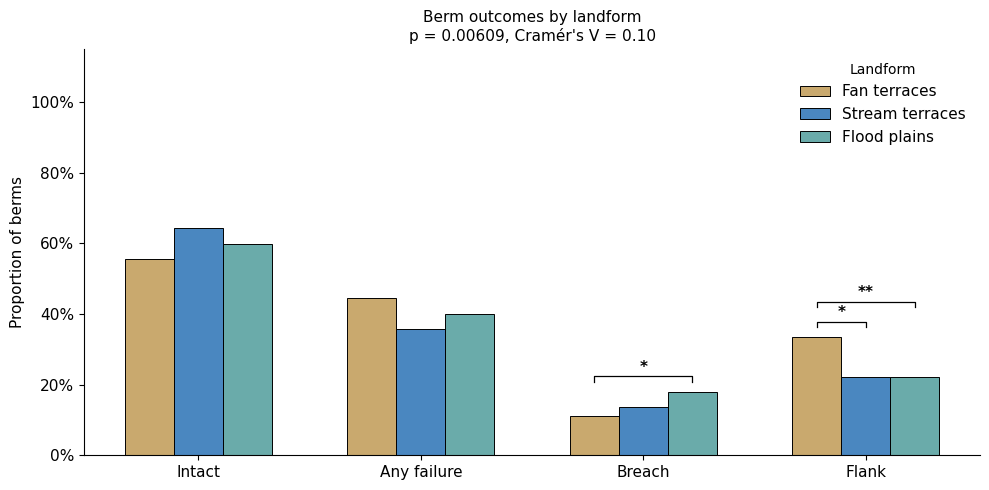

Saved: fig4_landform_fail_type.png


In [43]:
# ── Landform × Failure type figure: grouped bars with brackets ────────────────
_FS = FS

_plot_metrics_lf = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(10, 5))

_n_lf_bars = len(lf_order)
_w = 0.22
_offsets = np.linspace(-(_n_lf_bars - 1) * _w / 2,
                       (_n_lf_bars - 1) * _w / 2, _n_lf_bars)
_x = np.arange(len(_plot_metrics_lf))

for _li, _lf in enumerate(lf_order):
    _vals = [lf_metrics.loc[m, _lf] for m in _plot_metrics_lf]
    ax.bar(_x + _offsets[_li], _vals, _w, label=_lf,
           color=LF_COLORS.get(_lf, '#aaaaaa'), edgecolor='black', linewidth=0.7)

# Pairwise significance brackets per metric
_bh = 0.015
for _mi, _metric in enumerate(_plot_metrics_lf):
    _pairs = list(_combinations(range(_n_lf_bars), 2))
    _pairs.sort(key=lambda p: abs(_offsets[p[1]] - _offsets[p[0]]))
    _current_top = max(lf_metrics.loc[_metric, _lf] for _lf in lf_order) + 0.03
    for _ci, _cj in _pairs:
        _la, _lb = lf_order[_ci], lf_order[_cj]
        _sig_key = f'{_la[:2]}v{_lb[:2]} sig'
        _stars = lf_metrics.loc[_metric, _sig_key]
        if _stars == 'ns':
            continue
        _x_a = _mi + _offsets[_ci]
        _x_b = _mi + _offsets[_cj]
        _y_a = lf_metrics.loc[_metric, _la]
        _y_b = lf_metrics.loc[_metric, _lb]
        _yb = max(max(_y_a, _y_b) + 0.02, _current_top)
        ax.plot([_x_a, _x_a, _x_b, _x_b],
                [_yb, _yb + _bh, _yb + _bh, _yb], lw=0.9, color='black')
        ax.text((_x_a + _x_b) / 2, _yb + _bh + 0.005, _stars,
                ha='center', va='bottom', fontsize=_FS,
                fontweight='bold', color='black')
        _current_top = _yb + _bh + 0.04

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_lf, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f"Berm outcomes by landform\n{_p_str_lf}, Cram\u00e9r's V = {_V_lf:.2f}",
             fontsize=_FS)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Landform', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig4_landform_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig4', _fname,
    f'Grouped comparison of berm outcome proportions across landforms '
    f'({", ".join(lf_order)}) with pairwise one-sided Fisher exact '
    f'significance brackets. \u03c7\u00b2 = {_chi2_lf:.2f}, {_p_str_lf}, '
    f"Cram\u00e9r's V = {_V_lf:.2f}.",
    f'Outcome proportions compared by landform. Fan terraces show highest '
    f'flanking rate; flood plains highest breach rate.',
)
plt.show()
print(f'Saved: {_fname}')

### Length × Failure type

Fisher one-sided exact tests compare Long vs Short berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [44]:
# ── Length × Failure type: probability table + Fisher exact tests ────────────
_thr = 60

_df_len = df.query("Shape_Leng != @_thr").copy()
_df_len['len_bin'] = np.where(_df_len['Shape_Leng'] > _thr,
                              f'Long (>{_thr} m)', f'Short (<{_thr} m)')
_df_len['failed'] = _df_len['Fail_Type'].ne('Intact')

_long_lbl  = f'Long (>{_thr} m)'
_short_lbl = f'Short (<{_thr} m)'

_n_long  = len(_df_len[_df_len['len_bin'] == _long_lbl])
_n_short = len(_df_len[_df_len['len_bin'] == _short_lbl])

# Unconditional metrics
_rows = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_len)
    _c_l = _mask[_df_len['len_bin'] == _long_lbl].sum()
    _c_s = _mask[_df_len['len_bin'] == _short_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_l, _n_long, _c_s, _n_short)
    _p_l, _p_s = _c_l / _n_long, _c_s / _n_short
    _rows[_metric] = {
        _long_lbl: _p_l, _short_lbl: _p_s,
        '\u0394': round(_p_l - _p_s, 3),
        'direction': f"Long {'>' if _p_l >= _p_s else '<'} Short",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_f = _df_len[_df_len['failed']]
_n_lf = (_df_f['len_bin'] == _long_lbl).sum()
_n_sf = (_df_f['len_bin'] == _short_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_l = ((_df_f['Fail_Type'] == _ft) & (_df_f['len_bin'] == _long_lbl)).sum()
    _c_s = ((_df_f['Fail_Type'] == _ft) & (_df_f['len_bin'] == _short_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_l, _n_lf, _c_s, _n_sf)
    _p_l, _p_s = _c_l / _n_lf, _c_s / _n_sf
    _rows[_metric] = {
        _long_lbl: _p_l, _short_lbl: _p_s,
        '\u0394': round(_p_l - _p_s, 3),
        'direction': f"Long {'>' if _p_l >= _p_s else '<'} Short",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

len_metrics = pd.DataFrame(_rows).T
len_metrics[[_long_lbl, _short_lbl]] = len_metrics[[_long_lbl, _short_lbl]].astype(float)

display(len_metrics.assign(
    **{_long_lbl:  (len_metrics[_long_lbl]  * 100).round(1),
       _short_lbl: (len_metrics[_short_lbl] * 100).round(1),
       '\u0394':  len_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': len_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_long_lbl, _short_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,Long (>60 m),Short (<60 m),Δ,direction,p-value (1-sided),sig
Intact,47.1,70.4,-0.234,Long < Short,2.63e-11,***
Any failure,52.9,29.6,0.234,Long > Short,2.63e-11,***
Breach,21.8,8.0,0.138,Long > Short,3.78e-08,***
Flank,31.1,21.6,0.096,Long > Short,0.00161,**
Vegetation response,48.7,46.4,0.023,Long > Short,0.284,ns
Breach | failed,41.2,27.1,0.141,Long > Short,0.00765,**
Flank | failed,58.8,72.9,-0.141,Long < Short,0.00765,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 5)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


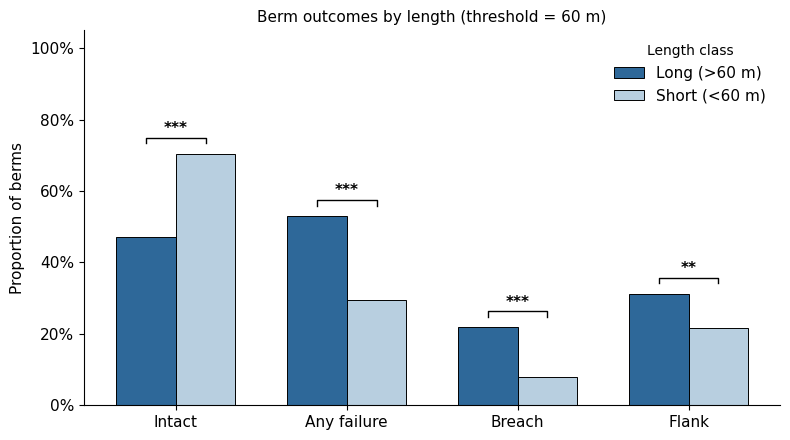

Saved: fig5_length_fail_type.png


In [45]:
# ── Length × Failure type figure: grouped bars with significance brackets ────
_FS = FS

_plot_metrics = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors = {_long_lbl:  LENGTH_COLORS['Long (> 60 m)'],
               _short_lbl: LENGTH_COLORS['Short (\u2264 60 m)']}
_x = np.arange(len(_plot_metrics))
_w = 0.35

for _lbl, _offset in [(_long_lbl, -_w / 2), (_short_lbl, _w / 2)]:
    _vals = [len_metrics.loc[m, _lbl] for m in _plot_metrics]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics):
    _sig = len_metrics.loc[_metric, 'sig']
    _p_l = len_metrics.loc[_metric, _long_lbl]
    _p_s = len_metrics.loc[_metric, _short_lbl]
    _top = max(_p_l, _p_s) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title(f'Berm outcomes by length (threshold = {_thr} m)', fontsize=_FS)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Length class', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig5_length_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig5', _fname,
    f'Grouped comparison of berm outcome proportions between Long and Short '
    f'berm classes (threshold {_thr} m), with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions differ by length class. Longer berms show higher '
    f'failure rates and a greater breach share among failures.',
)
plt.show()
print(f'Saved: {_fname}')

### Slope × Failure type

Fisher one-sided exact tests compare Steep vs Shallow berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [46]:
# ── Slope × Failure type: probability table + Fisher exact tests ─────────────
_shallow_lbl = 'Shallow (\u2264 2%)'
_steep_lbl   = 'Steep (> 2%)'

_df_slope = df.dropna(subset=['Slope_Class']).copy()
_df_slope['failed'] = _df_slope['Fail_Type'].ne('Intact')

_n_steep   = (_df_slope['Slope_Class'] == _steep_lbl).sum()
_n_shallow = (_df_slope['Slope_Class'] == _shallow_lbl).sum()

# Unconditional metrics
_rows_sl = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_slope)
    _c_st = _mask[_df_slope['Slope_Class'] == _steep_lbl].sum()
    _c_sh = _mask[_df_slope['Slope_Class'] == _shallow_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_st, _n_steep, _c_sh, _n_shallow)
    _p_st, _p_sh = _c_st / _n_steep, _c_sh / _n_shallow
    _rows_sl[_metric] = {
        _steep_lbl: _p_st, _shallow_lbl: _p_sh,
        '\u0394': round(_p_st - _p_sh, 3),
        'direction': f"Steep {'>' if _p_st >= _p_sh else '<'} Shallow",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_sf = _df_slope[_df_slope['failed']]
_n_stf = (_df_sf['Slope_Class'] == _steep_lbl).sum()
_n_shf = (_df_sf['Slope_Class'] == _shallow_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_st = ((_df_sf['Fail_Type'] == _ft) & (_df_sf['Slope_Class'] == _steep_lbl)).sum()
    _c_sh = ((_df_sf['Fail_Type'] == _ft) & (_df_sf['Slope_Class'] == _shallow_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_st, _n_stf, _c_sh, _n_shf)
    _p_st, _p_sh = _c_st / _n_stf, _c_sh / _n_shf
    _rows_sl[_metric] = {
        _steep_lbl: _p_st, _shallow_lbl: _p_sh,
        '\u0394': round(_p_st - _p_sh, 3),
        'direction': f"Steep {'>' if _p_st >= _p_sh else '<'} Shallow",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

slope_metrics = pd.DataFrame(_rows_sl).T
slope_metrics[[_steep_lbl, _shallow_lbl]] = slope_metrics[[_steep_lbl, _shallow_lbl]].astype(float)

display(slope_metrics.assign(
    **{_steep_lbl:   (slope_metrics[_steep_lbl]   * 100).round(1),
       _shallow_lbl: (slope_metrics[_shallow_lbl] * 100).round(1),
       '\u0394':  slope_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': slope_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_steep_lbl, _shallow_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,Steep (> 2%),Shallow (≤ 2%),Δ,direction,p-value (1-sided),sig
Intact,55.0,63.3,-0.083,Steep < Shallow,0.0114,*
Any failure,45.0,36.7,0.083,Steep > Shallow,0.0114,*
Breach,13.0,16.4,-0.034,Steep < Shallow,0.111,ns
Flank,32.0,20.3,0.117,Steep > Shallow,0.000147,***
Vegetation response,57.0,37.8,0.193,Steep > Shallow,5.3e-08,***
Breach | failed,29.0,44.7,-0.157,Steep < Shallow,0.00275,**
Flank | failed,71.0,55.3,0.157,Steep > Shallow,0.00275,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 6)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


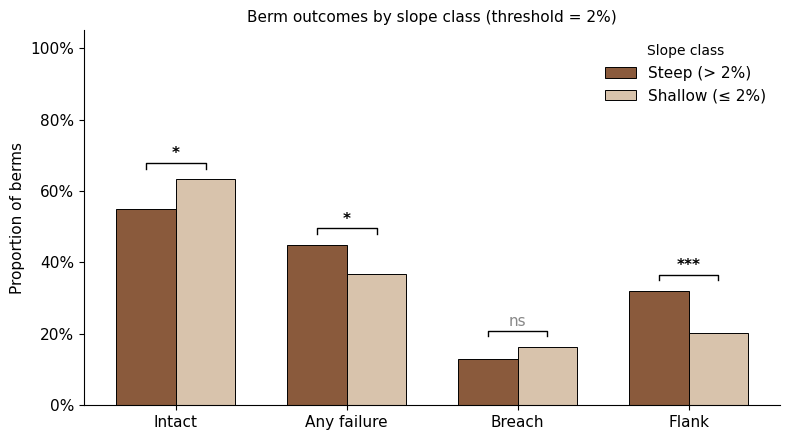

Saved: fig6_slope_fail_type.png


In [47]:
# ── Slope × Failure type figure: grouped bars with significance brackets ─────
_FS = FS

_plot_metrics_sl = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors_sl = {_steep_lbl:   SLOPE_COLORS['Steep (> 2%)'],
                  _shallow_lbl: SLOPE_COLORS['Shallow (\u2264 2%)']}
_x = np.arange(len(_plot_metrics_sl))
_w = 0.35

for _lbl, _offset in [(_steep_lbl, -_w / 2), (_shallow_lbl, _w / 2)]:
    _vals = [slope_metrics.loc[m, _lbl] for m in _plot_metrics_sl]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors_sl[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics_sl):
    _sig = slope_metrics.loc[_metric, 'sig']
    _p_st = slope_metrics.loc[_metric, _steep_lbl]
    _p_sh = slope_metrics.loc[_metric, _shallow_lbl]
    _top = max(_p_st, _p_sh) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_sl, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title('Berm outcomes by slope class (threshold = 2%)', fontsize=_FS)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Slope class', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig6_slope_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig6', _fname,
    f'Grouped comparison of berm outcome proportions between Steep and Shallow '
    f'slope classes (threshold 2%), with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions compared by slope class. Steeper slopes may show '
    f'different failure rates and failure type distributions.',
)
plt.show()
print(f'Saved: {_fname}')

### Soil development (B horizon) × Failure type

Fisher one-sided exact tests compare B horizon vs No B horizon berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [48]:
# ── Soil development × Failure type: probability table + Fisher exact tests ──
_bhor_lbl   = 'B horizon'
_nobhor_lbl = 'No B horizon'

_df_sd = df.dropna(subset=['Soil_Development']).copy()
_df_sd['failed'] = _df_sd['Fail_Type'].ne('Intact')

_n_bh  = (_df_sd['Soil_Development'] == _bhor_lbl).sum()
_n_nbh = (_df_sd['Soil_Development'] == _nobhor_lbl).sum()

# Unconditional metrics
_rows_sd = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_sd)
    _c_bh  = _mask[_df_sd['Soil_Development'] == _bhor_lbl].sum()
    _c_nbh = _mask[_df_sd['Soil_Development'] == _nobhor_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_bh, _n_bh, _c_nbh, _n_nbh)
    _p_bh, _p_nbh = _c_bh / _n_bh, _c_nbh / _n_nbh
    _rows_sd[_metric] = {
        _bhor_lbl: _p_bh, _nobhor_lbl: _p_nbh,
        '\u0394': round(_p_bh - _p_nbh, 3),
        'direction': f"B hor {'>' if _p_bh >= _p_nbh else '<'} No B hor",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_sdf = _df_sd[_df_sd['failed']]
_n_bhf  = (_df_sdf['Soil_Development'] == _bhor_lbl).sum()
_n_nbhf = (_df_sdf['Soil_Development'] == _nobhor_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_bh  = ((_df_sdf['Fail_Type'] == _ft) & (_df_sdf['Soil_Development'] == _bhor_lbl)).sum()
    _c_nbh = ((_df_sdf['Fail_Type'] == _ft) & (_df_sdf['Soil_Development'] == _nobhor_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_bh, _n_bhf, _c_nbh, _n_nbhf)
    _p_bh, _p_nbh = _c_bh / _n_bhf, _c_nbh / _n_nbhf
    _rows_sd[_metric] = {
        _bhor_lbl: _p_bh, _nobhor_lbl: _p_nbh,
        '\u0394': round(_p_bh - _p_nbh, 3),
        'direction': f"B hor {'>' if _p_bh >= _p_nbh else '<'} No B hor",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

sd_metrics = pd.DataFrame(_rows_sd).T
sd_metrics[[_bhor_lbl, _nobhor_lbl]] = sd_metrics[[_bhor_lbl, _nobhor_lbl]].astype(float)

display(sd_metrics.assign(
    **{_bhor_lbl:   (sd_metrics[_bhor_lbl]   * 100).round(1),
       _nobhor_lbl: (sd_metrics[_nobhor_lbl] * 100).round(1),
       '\u0394':  sd_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': sd_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_bhor_lbl, _nobhor_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

,B horizon,No B horizon,Δ,direction,p-value (1-sided),sig
Intact,54.7,61.7,-0.071,B hor < No B hor,0.0318,*
Any failure,45.3,38.3,0.071,B hor > No B hor,0.0318,*
Breach,11.8,16.5,-0.047,B hor < No B hor,0.0452,*
Flank,33.6,21.8,0.118,B hor > No B hor,0.000245,***
Vegetation response,55.4,42.8,0.126,B hor > No B hor,0.000459,***
Breach | failed,26.0,43.0,-0.171,B hor < No B hor,0.00125,**
Flank | failed,74.0,57.0,0.171,B hor > No B hor,0.00125,**


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 7)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


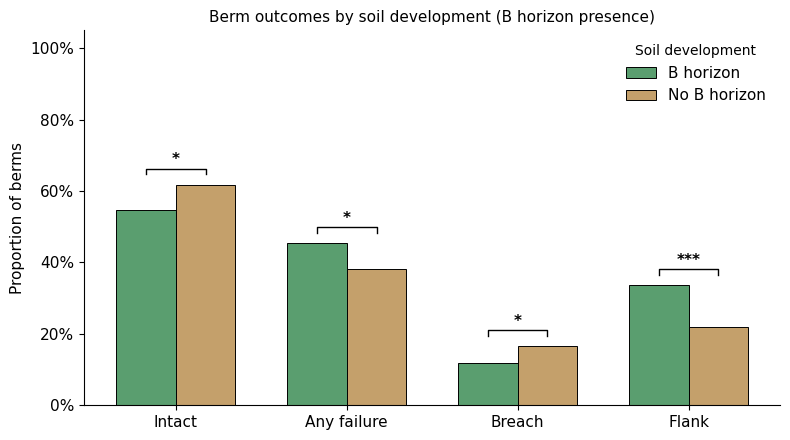

Saved: fig7_soildev_fail_type.png


In [49]:
# ── Soil development × Failure type figure: grouped bars with brackets ────────
_FS = FS

_plot_metrics_sd = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors_sd = {_bhor_lbl:   SOILDEV_COLORS['B horizon'],
                  _nobhor_lbl: SOILDEV_COLORS['No B horizon']}
_x = np.arange(len(_plot_metrics_sd))
_w = 0.35

for _lbl, _offset in [(_bhor_lbl, -_w / 2), (_nobhor_lbl, _w / 2)]:
    _vals = [sd_metrics.loc[m, _lbl] for m in _plot_metrics_sd]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors_sd[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics_sd):
    _sig = sd_metrics.loc[_metric, 'sig']
    _p_bh  = sd_metrics.loc[_metric, _bhor_lbl]
    _p_nbh = sd_metrics.loc[_metric, _nobhor_lbl]
    _top = max(_p_bh, _p_nbh) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_sd, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title('Berm outcomes by soil development (B horizon presence)', fontsize=_FS)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Soil development', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig7_soildev_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig7', _fname,
    f'Grouped comparison of berm outcome proportions between B horizon and '
    f'No B horizon soil classes, with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions compared by soil development. B horizon presence '
    f'may influence failure rates and failure type distributions.',
)
plt.show()
print(f'Saved: {_fname}')

## 100 % Stacked Bar — Fail_Type Composition by Landform

A proportional (100 %) stacked bar chart complements the grouped-bar view
by showing the *relative* composition of Intact / Breach / Flank within
each landform, making it easier to compare failure-mode ratios.

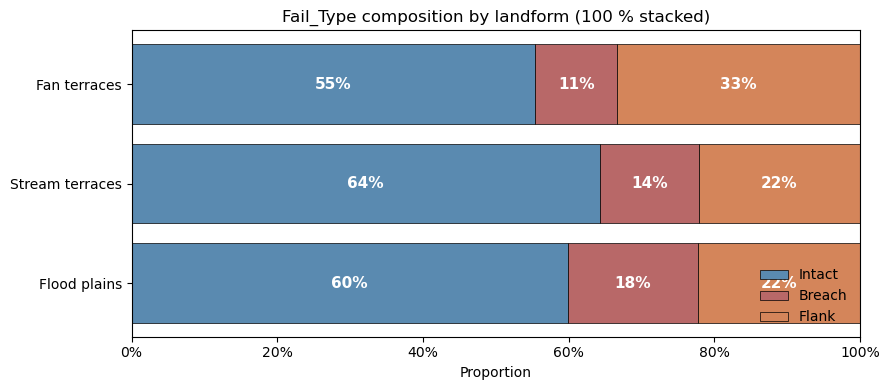

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 8)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_stacked_fail_by_landform.png


In [50]:
# ── 100 % stacked horizontal bar chart: Fail_Type by Landform ─────────────────
_ct_stack = pd.crosstab(df['Landform'], df['Fail_Type'])[fail_order]
_props = _ct_stack.div(_ct_stack.sum(axis=1), axis=0)
_props = _props.loc[lf_order]

_fig_stk, _ax_stk = plt.subplots(figsize=(9, 4))
_y = np.arange(len(lf_order))
_left = np.zeros(len(lf_order))
for _ft in fail_order:
    _vals = _props[_ft].values
    _ax_stk.barh(_y, _vals, left=_left, color=fail_colors[_ft],
                 edgecolor='black', linewidth=0.5, label=_ft)
    # annotate percentage inside each segment
    for _j, (_v, _l) in enumerate(zip(_vals, _left)):
        if _v > 0.04:
            _ax_stk.text(_l + _v / 2, _j, f'{_v:.0%}', ha='center', va='center',
                         fontsize=FS, fontweight='bold', color='white')
    _left += _vals

_ax_stk.set_yticks(_y)
_ax_stk.set_yticklabels(lf_order)
_ax_stk.set_xlabel('Proportion')
_ax_stk.set_title('Fail_Type composition by landform (100 % stacked)')
_ax_stk.legend(frameon=False, loc='lower right')
_ax_stk.set_xlim(0, 1)
_ax_stk.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
_ax_stk.invert_yaxis()
plt.tight_layout()
plt.show()

# Save & register
_fname_stk = 'fig_stacked_fail_by_landform.png'
_fig_stk.savefig(_os.path.join(_fig_dir, _fname_stk), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig8', _fname_stk,
    '100 % stacked bar chart showing relative Intact / Breach / Flank '
    'composition within each landform.',
    'Proportional failure-type composition by landform. '
    'Flood plains have the highest breach share; fan terraces the highest flank share.',
)
print(f'Saved: {_fname_stk}')

## Continuous Predictors × Fail_Type

The following sections analyse continuous site-level variables against the
three-level failure type using **Kruskal-Wallis** tests (non-parametric
one-way ANOVA) with **pairwise Mann-Whitney** post-hoc tests and
Benjamini–Hochberg FDR correction.

### Berm Angle (Directionality)

`berm_angle` measures the compass alignment of each berm relative to the
contour. The absolute value (`abs_angle`) captures how far from
perpendicular a berm is oriented, regardless of left/right direction.

In [51]:
# ── Berm angle (directionality) × Fail_Type ───────────────────────────────────
df['abs_angle'] = np.abs(df['berm_angle'])
print('=== Absolute berm angle × Fail_Type ===')
_res_angle = _continuous_by_failtype(df, 'abs_angle', label='|berm_angle|')

=== Absolute berm angle × Fail_Type ===
Kruskal-Wallis  H = 28.96,  p = 5.14e-07
  Group medians:
    Intact  : median = 36.673  (n = 458)
    Breach  : median = 26.187  (n = 114)
    Flank   : median = 57.380  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,28829.0,0.0847,0.0,True
1,Breach,Flank,8036.0,0.0000,0.0,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


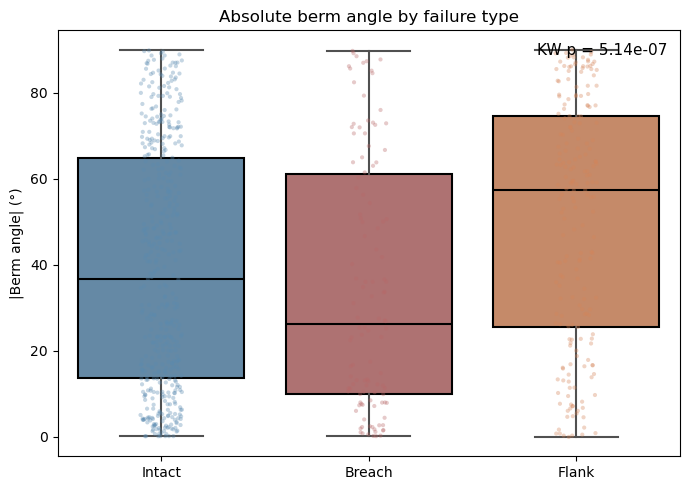

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 9)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_angle_fail_type.png


In [52]:
# ── Berm angle × Fail_Type figure ─────────────────────────────────────────────
_fig_ang, _ax_ang = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_ang, df.dropna(subset=['abs_angle']),
                             'abs_angle',
                             title='Absolute berm angle by failure type',
                             ylabel='|Berm angle| (°)')
if _res_angle:
    _ax_ang.text(0.98, 0.97, f'KW p = {_res_angle["p_kw"]:.3g}',
                 transform=_ax_ang.transAxes, ha='right', va='top', fontsize=FS)
plt.tight_layout()
plt.show()

_fname_ang = 'fig_angle_fail_type.png'
_fig_ang.savefig(_os.path.join(_fig_dir, _fname_ang), dpi=300, bbox_inches='tight')

_p_str = f'{_res_angle["p_kw"]:.3g}' if _res_angle else 'N/A'
register_failure_mechanisms_figure(
    'fig9', _fname_ang,
    f'Absolute berm angle by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of berm directionality by Fail_Type. '
    f'Tests whether berms farther from perpendicular are more prone to a specific failure mode.',
)
print(f'Saved: {_fname_ang}')

### Flow Accumulation

Upstream flow accumulation (`FA_30_mean`) measures the total contributing
drainage area reaching each berm (TauDEM, 30 m DEM). Higher values indicate
berms that intercept larger catchments and potentially greater runoff volume.
The variable is log-transformed (`log1p`) to address extreme right-skew
(range ~1 to >1 000 000).

In [53]:
# ── Flow accumulation × Fail_Type ─────────────────────────────────────────────
df['logFA'] = np.log1p(df['FA_30_mean'])
print('=== log(1 + FA_30_mean) × Fail_Type ===')
_res_fa = _continuous_by_failtype(df, 'logFA', label='log(FA_30_mean)')

=== log(1 + FA_30_mean) × Fail_Type ===
Kruskal-Wallis  H = 42.89,  p = 4.86e-10
  Group medians:
    Intact  : median = 4.781  (n = 458)
    Breach  : median = 6.213  (n = 114)
    Flank   : median = 5.881  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,18817.0,0.0,0.0,True
1,Intact,Flank,33713.0,0.0,0.0,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


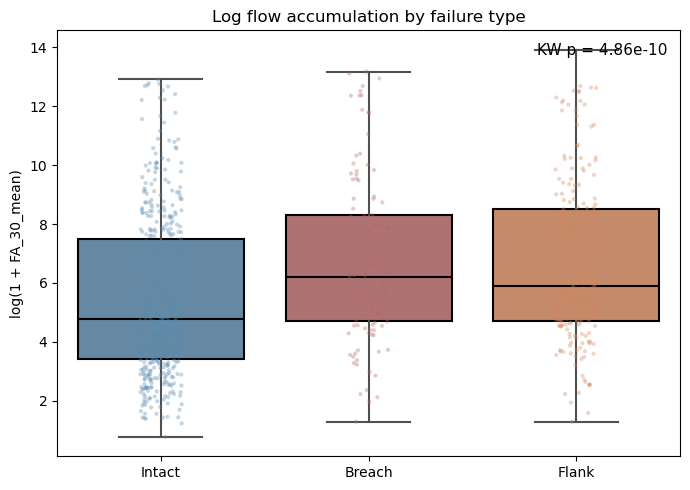

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 10)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_flowaccum_fail_type.png


In [54]:
# ── Flow accumulation × Fail_Type figure ──────────────────────────────────────
_fig_fa, _ax_fa = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_fa, df.dropna(subset=['logFA']),
                             'logFA',
                             title='Log flow accumulation by failure type',
                             ylabel='log(1 + FA_30_mean)')
if _res_fa:
    _ax_fa.text(0.98, 0.97, f'KW p = {_res_fa["p_kw"]:.3g}',
                transform=_ax_fa.transAxes, ha='right', va='top', fontsize=FS)
plt.tight_layout()
plt.show()

_fname_fa = 'fig_flowaccum_fail_type.png'
_fig_fa.savefig(_os.path.join(_fig_dir, _fname_fa), dpi=300, bbox_inches='tight')

_p_str = f'{_res_fa["p_kw"]:.3g}' if _res_fa else 'N/A'
register_failure_mechanisms_figure(
    'fig10', _fname_fa,
    f'Log flow accumulation by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of log-transformed upstream flow accumulation by Fail_Type. '
    f'Tests whether berms with larger contributing catchments are more prone to breach or flank.',
)
print(f'Saved: {_fname_fa}')

### SAVI Vegetation Indices

Soil-Adjusted Vegetation Index (SAVI) measured upstream (`saviU_60`) and
downstream (`saviD_60`) of each berm in a 60 m buffer, plus a reference
background (`savi_background`). The normalised vegetation effect
`(saviU − saviD) / savi_background` quantifies relative vegetation
response attributable to each berm.

In [55]:
# ── SAVI vegetation × Fail_Type ───────────────────────────────────────────────
print('=== Downstream SAVI (saviD_60) × Fail_Type ===')
_res_savi_d = _continuous_by_failtype(df, 'saviD_60', label='Downstream SAVI')

print('\n=== Upstream SAVI (saviU_60) × Fail_Type ===')
_res_savi_u = _continuous_by_failtype(df, 'saviU_60', label='Upstream SAVI')

# Vegetation effect (normalised)
if 'effect' not in df.columns:
    df['effect'] = (df['saviU_60'] - df['saviD_60']) / df['savi_background']
print('\n=== Vegetation effect × Fail_Type ===')
_res_veg_eff = _continuous_by_failtype(df, 'effect', label='Veg effect')

=== Downstream SAVI (saviD_60) × Fail_Type ===
Kruskal-Wallis  H = 1.95,  p = 0.377
  Group medians:
    Intact  : median = 0.147  (n = 458)
    Breach  : median = 0.143  (n = 114)
    Flank   : median = 0.143  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)

=== Upstream SAVI (saviU_60) × Fail_Type ===
Kruskal-Wallis  H = 0.27,  p = 0.876
  Group medians:
    Intact  : median = 0.158  (n = 458)
    Breach  : median = 0.155  (n = 114)
    Flank   : median = 0.159  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)

=== Vegetation effect × Fail_Type ===
Kruskal-Wallis  H = 0.19,  p = 0.911
  Group medians:
    Intact  : median = 0.058  (n = 458)
    Breach  : median = 0.070  (n = 114)
    Flank   : median = 0.059  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


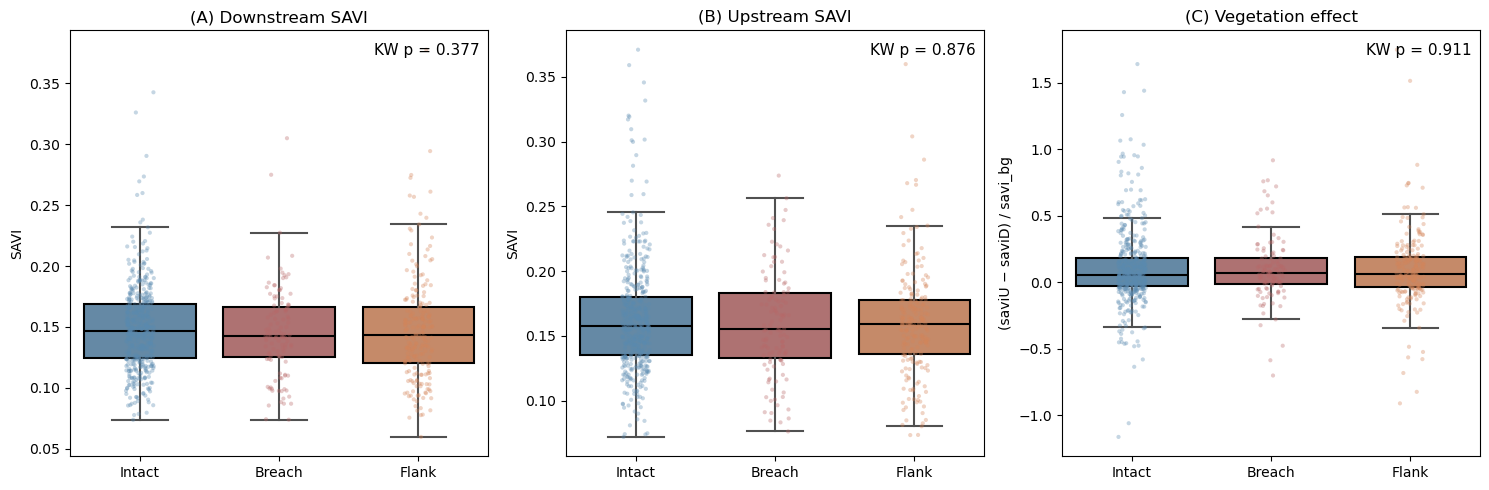

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 11)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_savi_fail_type.png


In [56]:
# ── SAVI × Fail_Type figure (3-panel: downstream, upstream, veg effect) ──────
_fig_savi, (_ax_s1, _ax_s2, _ax_s3) = plt.subplots(1, 3, figsize=(15, 5))

_plot_continuous_by_failtype(_ax_s1, df.dropna(subset=['saviD_60']),
                             'saviD_60',
                             title='(A) Downstream SAVI',
                             ylabel='SAVI')
if _res_savi_d:
    _ax_s1.text(0.98, 0.97, f'KW p = {_res_savi_d["p_kw"]:.3g}',
                transform=_ax_s1.transAxes, ha='right', va='top', fontsize=FS)

_plot_continuous_by_failtype(_ax_s2, df.dropna(subset=['saviU_60']),
                             'saviU_60',
                             title='(B) Upstream SAVI',
                             ylabel='SAVI')
if _res_savi_u:
    _ax_s2.text(0.98, 0.97, f'KW p = {_res_savi_u["p_kw"]:.3g}',
                transform=_ax_s2.transAxes, ha='right', va='top', fontsize=FS)

_plot_continuous_by_failtype(_ax_s3, df.dropna(subset=['effect']),
                             'effect',
                             title='(C) Vegetation effect',
                             ylabel='(saviU − saviD) / savi_bg')
if _res_veg_eff:
    _ax_s3.text(0.98, 0.97, f'KW p = {_res_veg_eff["p_kw"]:.3g}',
                transform=_ax_s3.transAxes, ha='right', va='top', fontsize=FS)

plt.tight_layout()
plt.show()

_fname_savi = 'fig_savi_fail_type.png'
_fig_savi.savefig(_os.path.join(_fig_dir, _fname_savi), dpi=300, bbox_inches='tight')

_p_d = f'{_res_savi_d["p_kw"]:.3g}' if _res_savi_d else 'N/A'
_p_u = f'{_res_savi_u["p_kw"]:.3g}' if _res_savi_u else 'N/A'
_p_e = f'{_res_veg_eff["p_kw"]:.3g}' if _res_veg_eff else 'N/A'
register_failure_mechanisms_figure(
    'fig11', _fname_savi,
    f'SAVI vegetation indices by failure type. KW p: downstream = {_p_d}, '
    f'upstream = {_p_u}, veg effect = {_p_e}.',
    f'Three-panel view of downstream SAVI, upstream SAVI, and normalised '
    f'vegetation effect by Fail_Type.',
)
print(f'Saved: {_fname_savi}')

### Road Distance

Distance to the nearest road (`road_dist`, metres). Roads may concentrate or
redirect flow, influencing whether adjacent berms fail by breaching or flanking.

In [57]:
# ── Road distance × Fail_Type ─────────────────────────────────────────────────
print('=== Road distance × Fail_Type ===')
_res_road = _continuous_by_failtype(df, 'road_dist', label='road_dist (m)')

=== Road distance × Fail_Type ===
Kruskal-Wallis  H = 9.42,  p = 0.00901
  Group medians:
    Intact  : median = 253.904  (n = 458)
    Breach  : median = 326.662  (n = 114)
    Flank   : median = 236.441  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,21330.0,0.0025,0.0075,True
1,Breach,Flank,13568.0,0.0108,0.0162,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_98753/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


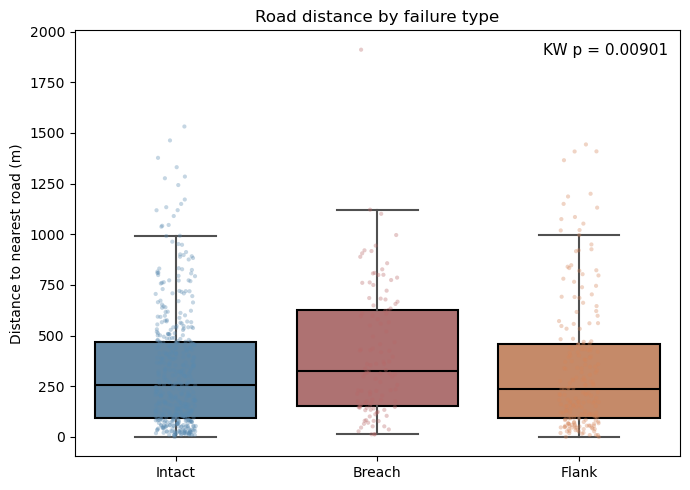

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 12)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_roaddist_fail_type.png


In [58]:
# ── Road distance × Fail_Type figure ──────────────────────────────────────────
_fig_rd, _ax_rd = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_rd, df.dropna(subset=['road_dist']),
                             'road_dist',
                             title='Road distance by failure type',
                             ylabel='Distance to nearest road (m)')
if _res_road:
    _ax_rd.text(0.98, 0.97, f'KW p = {_res_road["p_kw"]:.3g}',
                transform=_ax_rd.transAxes, ha='right', va='top', fontsize=FS)
plt.tight_layout()
plt.show()

_fname_rd = 'fig_roaddist_fail_type.png'
_fig_rd.savefig(_os.path.join(_fig_dir, _fname_rd), dpi=300, bbox_inches='tight')

_p_str = f'{_res_road["p_kw"]:.3g}' if _res_road else 'N/A'
register_failure_mechanisms_figure(
    'fig12', _fname_rd,
    f'Road distance by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of distance to nearest road by Fail_Type. '
    f'Tests whether road proximity influences failure mode.',
)
print(f'Saved: {_fname_rd}')

### High Clay × Failure type

Fisher one-sided exact tests compare High Clay vs Low Clay berm outcomes.
Metrics include both unconditional (all berms) and conditional
(among failed berms only) probabilities.

In [59]:
# ── High Clay × Failure type: probability table + Fisher exact tests ──────────
_hc_lbl  = 'High Clay'
_lc_lbl  = 'Low Clay'

_df_hc = df.dropna(subset=['High_Clay', 'Fail_Type']).copy()
_df_hc['Clay_Level'] = _df_hc['High_Clay'].map({True: _hc_lbl, False: _lc_lbl})
_df_hc['failed'] = _df_hc['Fail_Type'].ne('Intact')

_n_hc = (_df_hc['Clay_Level'] == _hc_lbl).sum()
_n_lc = (_df_hc['Clay_Level'] == _lc_lbl).sum()

# Overall chi-square (for SI export compatibility)
_ct_hc = pd.crosstab(_df_hc['Clay_Level'], _df_hc['Fail_Type'])[fail_order]
_chi2_hc, _p_hc, _dof_hc, _V_hc, _ = chi2_with_cramers_v(_ct_hc)
print(f'χ²({_dof_hc}) = {_chi2_hc:.2f},  p = {_p_hc:.3g},  Cramér\'s V = {_V_hc:.3f}\n')

# Unconditional metrics
_rows_hc = {}
for _metric, _pos_fn in [
    ('Intact',       lambda d: d['Fail_Type'] == 'Intact'),
    ('Any failure',  lambda d: d['failed']),
    ('Breach',       lambda d: d['Fail_Type'] == 'Breach'),
    ('Flank',        lambda d: d['Fail_Type'] == 'Flank'),
    (LBL_EFFECTIVE,  lambda d: d['Effective'] == LBL_EFFECTIVE),
]:
    _mask = _pos_fn(_df_hc)
    _c_hc = _mask[_df_hc['Clay_Level'] == _hc_lbl].sum()
    _c_lc = _mask[_df_hc['Clay_Level'] == _lc_lbl].sum()
    _p_val, _direction = _fisher_one_sided(_c_hc, _n_hc, _c_lc, _n_lc)
    _p_hcv, _p_lcv = _c_hc / _n_hc, _c_lc / _n_lc
    _rows_hc[_metric] = {
        _hc_lbl: _p_hcv, _lc_lbl: _p_lcv,
        '\u0394': round(_p_hcv - _p_lcv, 3),
        'direction': f"High {'>' if _p_hcv >= _p_lcv else '<'} Low",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

# Conditional metrics (among failed only)
_df_hcf = _df_hc[_df_hc['failed']]
_n_hcf = (_df_hcf['Clay_Level'] == _hc_lbl).sum()
_n_lcf = (_df_hcf['Clay_Level'] == _lc_lbl).sum()
for _metric, _ft in [('Breach | failed', 'Breach'), ('Flank | failed', 'Flank')]:
    _c_hc = ((_df_hcf['Fail_Type'] == _ft) & (_df_hcf['Clay_Level'] == _hc_lbl)).sum()
    _c_lc = ((_df_hcf['Fail_Type'] == _ft) & (_df_hcf['Clay_Level'] == _lc_lbl)).sum()
    _p_val, _direction = _fisher_one_sided(_c_hc, _n_hcf, _c_lc, _n_lcf)
    _p_hcv, _p_lcv = _c_hc / _n_hcf, _c_lc / _n_lcf
    _rows_hc[_metric] = {
        _hc_lbl: _p_hcv, _lc_lbl: _p_lcv,
        '\u0394': round(_p_hcv - _p_lcv, 3),
        'direction': f"High {'>' if _p_hcv >= _p_lcv else '<'} Low",
        'p-value (1-sided)': _p_val,
        'sig': _sig_stars(_p_val),
    }

hc_metrics = pd.DataFrame(_rows_hc).T
hc_metrics[[_hc_lbl, _lc_lbl]] = hc_metrics[[_hc_lbl, _lc_lbl]].astype(float)

display(hc_metrics.assign(
    **{_hc_lbl:  (hc_metrics[_hc_lbl]  * 100).round(1),
       _lc_lbl:  (hc_metrics[_lc_lbl]  * 100).round(1),
       '\u0394': hc_metrics['\u0394'].astype(float).round(3),
       'p-value (1-sided)': hc_metrics['p-value (1-sided)'].apply(lambda x: f'{x:.3g}')}
)[[_hc_lbl, _lc_lbl, '\u0394', 'direction', 'p-value (1-sided)', 'sig']])

χ²(2) = 18.49,  p = 9.66e-05,  Cramér's V = 0.154



,High Clay,Low Clay,Δ,direction,p-value (1-sided),sig
Intact,64.8,54.5,0.103,High > Low,0.00232,**
Any failure,35.2,45.5,-0.103,High < Low,0.00232,**
Breach,16.6,13.2,0.033,High > Low,0.114,ns
Flank,18.6,32.3,-0.136,High < Low,1.05e-05,***
Vegetation response,39.5,53.8,-0.143,High < Low,4.91e-05,***
Breach | failed,47.1,29.1,0.180,High > Low,0.000916,***
Flank | failed,52.9,70.9,-0.180,High < Low,0.000916,***


Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 13)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt


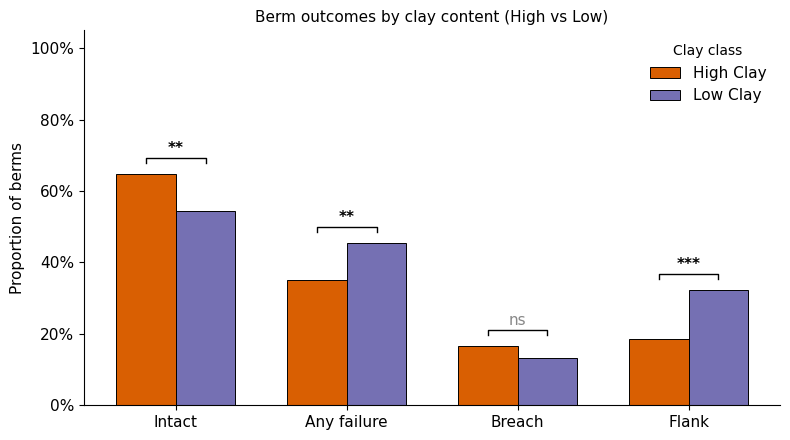

Saved: fig13_highclay_fail_type.png


In [60]:
# ── High Clay × Failure type figure: grouped bars with significance brackets ──
_FS = FS

_plot_metrics_hc = ['Intact', 'Any failure', 'Breach', 'Flank']

fig, ax = plt.subplots(figsize=(8, 4.5))

_bar_colors_hc = {_hc_lbl: CLAY_COLORS.get('High Clay', '#d95f02'),
                  _lc_lbl: CLAY_COLORS.get('Low Clay', '#7570b3')}
_x = np.arange(len(_plot_metrics_hc))
_w = 0.35

for _lbl, _offset in [(_hc_lbl, -_w / 2), (_lc_lbl, _w / 2)]:
    _vals = [hc_metrics.loc[m, _lbl] for m in _plot_metrics_hc]
    ax.bar(_x + _offset, _vals, _w, label=_lbl,
           color=_bar_colors_hc[_lbl], edgecolor='black', linewidth=0.7)

# Significance brackets
for _i, _metric in enumerate(_plot_metrics_hc):
    _sig = hc_metrics.loc[_metric, 'sig']
    _p_hcv = hc_metrics.loc[_metric, _hc_lbl]
    _p_lcv = hc_metrics.loc[_metric, _lc_lbl]
    _top = max(_p_hcv, _p_lcv) + 0.03
    _bh  = 0.015
    ax.plot([_x[_i] - _w/2, _x[_i] - _w/2, _x[_i] + _w/2, _x[_i] + _w/2],
            [_top, _top + _bh, _top + _bh, _top], lw=1, color='black')
    _col = 'black' if _sig != 'ns' else '#888888'
    ax.text(_x[_i], _top + _bh + 0.005, _sig, ha='center', va='bottom',
            fontsize=_FS, color=_col,
            fontweight='bold' if _sig != 'ns' else 'normal')

ax.set_xticks(_x)
ax.set_xticklabels(_plot_metrics_hc, fontsize=_FS)
ax.set_ylabel('Proportion of berms', fontsize=_FS)
ax.set_title('Berm outcomes by clay content (High vs Low)', fontsize=_FS)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.tick_params(labelsize=_FS)
ax.legend(title='Clay class', frameon=False, fontsize=_FS)
sns.despine(ax=ax)
plt.tight_layout()

_fname = 'fig13_highclay_fail_type.png'
fig.savefig(_os.path.join(_fig_dir, _fname), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig13', _fname,
    f'Grouped comparison of berm outcome proportions between High Clay and '
    f'Low Clay classes, with per-metric one-sided '
    f'Fisher exact significance brackets.',
    f'Outcome proportions compared by clay content. Higher clay soils may '
    f'influence failure rates and failure type distributions.',
)
plt.show()
print(f'Saved: {_fname}')

## Conditional Failure-Mode Probabilities

For each categorical predictor, compute:
- **P(Breach | failed)** and **P(Flank | failed)** per level — the share of
  failures that are breaches vs flanks.
- **Fisher exact odds ratio** (Breach vs Flank) comparing levels where sample
  size permits.

This extends the conditional approach used for `Berm_Length_Class` above to
all categorical predictors in a single summary table.

In [61]:
# ── Conditional P(Breach|failed), P(Flank|failed) for all categorical predictors
_cat_predictors = {
    'Texture':            [t for t in texture_order if t in _top3_tex],
    'Landform':           lf_order,
    'Berm_Length_Class':  length_order,
    'Slope_Class':        slope_order,
    'Soil_Development':   soildev_order,
}

_cond_rows = []
for _col, _levels in _cat_predictors.items():
    for _lv in _levels:
        _g = df.loc[(df[_col] == _lv) & (df['Fail_Type'] != 'Intact'), 'Fail_Type']
        _n_failed = len(_g)
        if _n_failed == 0:
            continue
        _n_breach = (_g == 'Breach').sum()
        _n_flank  = (_g == 'Flank').sum()
        _cond_rows.append({
            'Predictor': _col,
            'Level': _lv,
            'n_failed': _n_failed,
            'n_breach': _n_breach,
            'n_flank': _n_flank,
            'P(Breach|failed)': _n_breach / _n_failed,
            'P(Flank|failed)':  _n_flank  / _n_failed,
        })

_cond_df = pd.DataFrame(_cond_rows)
print('=== Conditional failure-mode probabilities ===')
display(_cond_df.round(3))

# ── Fisher exact OR for breach vs flank, comparing first and last level ──────
print('\n=== Fisher exact (Breach vs Flank) — first vs last level per predictor ===')
for _col, _levels in _cat_predictors.items():
    _sub = _cond_df.loc[_cond_df['Predictor'] == _col]
    if len(_sub) < 2:
        continue
    _first = _sub.iloc[0]
    _last  = _sub.iloc[-1]
    _table = np.array([
        [int(_first['n_breach']), int(_first['n_flank'])],
        [int(_last['n_breach']),  int(_last['n_flank'])],
    ])
    if _table.min() == 0:
        # add 0.5 continuity correction for zero cells
        _or_val, _p_val = fisher_exact(_table + 0.5)
    else:
        _or_val, _p_val = fisher_exact(_table)
    print(f'  {_col}: {_first["Level"]} vs {_last["Level"]}  →  '
          f'OR = {_or_val:.2f},  p = {_p_val:.3g}')

=== Conditional failure-mode probabilities ===


,Predictor,Level,n_failed,n_breach,n_flank,P(Breach|failed),P(Flank|failed)
0,Texture,Clay loam,108,53,55,0.491,0.509
1,Texture,Silt loam,49,19,30,0.388,0.612
2,Texture,Sandy loam,113,28,85,0.248,0.752
3,Landform,Fan terraces,123,31,92,0.252,0.748
4,Landform,Stream terraces,50,19,31,0.380,0.620
5,Landform,Flood plains,144,64,80,0.444,0.556
6,Berm_Length_Class,Short (≤ 60 m),118,32,86,0.271,0.729
7,Berm_Length_Class,Long (> 60 m),199,82,117,0.412,0.588
8,Slope_Class,Shallow (≤ 2%),141,63,78,0.447,0.553
9,Slope_Class,Steep (> 2%),176,51,125,0.290,0.710



=== Fisher exact (Breach vs Flank) — first vs last level per predictor ===
  Texture: Clay loam vs Sandy loam  →  OR = 2.93,  p = 0.00026
  Landform: Fan terraces vs Flood plains  →  OR = 0.42,  p = 0.00131
  Berm_Length_Class: Short (≤ 60 m) vs Long (> 60 m)  →  OR = 0.53,  p = 0.0153
  Slope_Class: Shallow (≤ 2%) vs Steep (> 2%)  →  OR = 1.98,  p = 0.00467
  Soil_Development: B horizon vs No B horizon  →  OR = 0.46,  p = 0.002


## Interaction Effects — Landform × Texture × Fail_Type

Do texture effects on failure mode differ across landforms? Within each
landform, we test whether the distribution of Fail_Type varies by texture
using Fisher exact tests (appropriate when expected counts are small in
stratified sub-tables).

In [62]:
# ── Within-landform Texture × Fail_Type stratified tests ──────────────────────
from scipy.stats import chi2_contingency as _chi2_contingency

_sub_int = df.loc[df['Texture'].isin(_top3_tex)].dropna(
    subset=['Landform', 'Texture', 'Fail_Type']).copy()

_int_rows = []
for _lf in lf_order:
    _lf_sub = _sub_int.loc[_sub_int['Landform'] == _lf]
    _ct_int = pd.crosstab(_lf_sub['Texture'], _lf_sub['Fail_Type'])
    # need at least 2 textures and 2 fail types present
    if _ct_int.shape[0] < 2 or _ct_int.shape[1] < 2:
        _int_rows.append({'Landform': _lf, 'n': len(_lf_sub),
                          'test': 'insufficient', 'p': float('nan')})
        continue
    # Use chi-square if expected counts ≥ 5, else Fisher (via simulate)
    _, _p_int, _, _exp = _chi2_contingency(_ct_int)
    if (_exp < 5).any():
        # Fisher–Freeman–Halton via chi-square with simulated p-value is not
        # available in scipy; fall back to chi-square but flag the issue.
        _method = 'chi2 (small expected)'
    else:
        _method = 'chi2'
    _int_rows.append({
        'Landform': _lf,
        'n': len(_lf_sub),
        'test': _method,
        'p': _p_int,
        'n_textures': _ct_int.shape[0],
        'n_fail_types': _ct_int.shape[1],
    })

_int_df = pd.DataFrame(_int_rows)
print('=== Within-landform Texture × Fail_Type tests ===')
display(_int_df.round(4))

_sig_int = _int_df.dropna(subset=['p'])
if len(_sig_int):
    _sig_int = _sig_int.copy()
    _sig_int['q_fdr'] = _bh_adjust(_sig_int['p'].values)
    _sig_int['significant'] = _sig_int['q_fdr'] < 0.05
    print('\nWith FDR correction:')
    display(_sig_int.round(4))

=== Within-landform Texture × Fail_Type tests ===


,Landform,n,test,p,n_textures,n_fail_types
0,Fan terraces,194,insufficient,NaN,NaN,NaN
1,Stream terraces,137,insufficient,NaN,NaN,NaN
2,Flood plains,299,chi2 (small expected),0.0121,2.0,3.0



With FDR correction:


,Landform,n,test,p,n_textures,n_fail_types,q_fdr,significant
2,Flood plains,299,chi2 (small expected),0.0121,2.0,3.0,0.0121,True


## Predicting breach vs flank — RF vs Logistic

Model comparison on the subset of **failed berms only** (Breach or Flank).
Target: `is_breach` (1 = breach, 0 = flank).

Compares Random Forest and L2-penalised Logistic Regression across four predictor
scenarios (geomorphology, soil, shape length, all combined).

In [63]:
# ── Model imports & pipeline builder ───────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from analysis import _coerce_binary, _unique_preserve

# ── Predictor scenario definitions ────────────────────────────────────────────
_treat_as = {'Shape_Leng': 'numeric', 'High_Clay': 'categorical'}

_geo_preds  = ['Landform', 'slope_200', 'FA_30_max', 'FA_60_max']
_soil_preds = ['Texture', 'Soil_Development', 'TypicalProfile',
               'profile_depth_cm', 'b_horizon_depth_cm', 'restriction_depth_cm']
_len_preds  = ['Shape_Leng', 'Berm_Length_Class']
_all_preds  = _unique_preserve(_geo_preds + _soil_preds + _len_preds)

_scenario_predictors = {
    'landscape_geomorphology_only': _geo_preds,
    'soil_only':                    _soil_preds,
    'shape_length_only':            _len_preds,
    'all_predictors':               _all_preds,
}

# ── Failed berms subset ──────────────────────────────────────────────────────
_df_fail = df.loc[df['Fail_Type'].isin(['Breach', 'Flank'])].copy()
_df_fail['is_breach'] = (_df_fail['Fail_Type'] == 'Breach').astype(int)
print(f'Failed berms: {len(_df_fail):,}  '
      f'(Breach {_df_fail["is_breach"].sum()}, Flank {(1 - _df_fail["is_breach"]).sum().astype(int)})')


def _build_pipeline(model_type, predictors, treat_as_map, source_df):
    cat_cols, num_cols = [], []
    for c in predictors:
        ta = treat_as_map.get(c)
        if ta == 'categorical':
            cat_cols.append(c)
        elif ta == 'numeric':
            num_cols.append(c)
        elif source_df[c].dtype == object or pd.api.types.is_string_dtype(source_df[c]):
            cat_cols.append(c)
        else:
            num_cols.append(c)
    pre = ColumnTransformer(transformers=[
        ('num', _Pipeline([('impute', SimpleImputer(strategy='median')),
                           ('scale', StandardScaler())]), num_cols),
        ('cat', _Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                           ('onehot', OneHotEncoder(handle_unknown='ignore',
                                                    sparse_output=False))]), cat_cols),
    ], remainder='drop')
    if model_type == 'RF':
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                     class_weight='balanced', random_state=0, n_jobs=-1)
    else:
        clf = LogisticRegression(C=1.0, penalty='l2', max_iter=2000,
                                 class_weight='balanced', solver='lbfgs', random_state=0)
    return _Pipeline([('pre', pre), ('clf', clf)])


def _fit_and_evaluate(model_type, predictors, target, treat_as_map, source_df,
                      test_size=0.25, random_state=0):
    sub = source_df[predictors + [target]].copy()
    sub[target] = _coerce_binary(sub[target])
    sub = sub.dropna(subset=[target])
    X, yv = sub[predictors], sub[target].astype(int)
    pipe = _build_pipeline(model_type, predictors, treat_as_map, source_df)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, yv, test_size=test_size, stratify=yv, random_state=random_state)
    pipe.fit(X_tr, y_tr)
    holdout_auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_scores = cross_validate(pipe, X, yv, cv=cv,
                               scoring={'auc': 'roc_auc', 'bal_acc': 'balanced_accuracy', 'f1': 'f1'},
                               n_jobs=-1, return_train_score=False)
    cv_summary = {k.replace('test_', ''): (float(np.mean(v)), float(np.std(v)))
                  for k, v in cv_scores.items() if k.startswith('test_')}
    pi = permutation_importance(pipe, X_te, y_te, scoring='roc_auc',
                                n_repeats=30, random_state=random_state, n_jobs=-1)
    pi_series = pd.Series(pi.importances_mean, index=predictors).sort_values(ascending=False)
    return pipe, {'cv': cv_summary, 'holdout': {'auc': float(holdout_auc)}, 'n': int(len(X))}, pi_series


print('Pipeline builder defined')

Failed berms: 317  (Breach 114, Flank 203)
Pipeline builder defined


In [64]:
# ── Baseline scenario sweep — breach vs flank ─────────────────────────────────
_model_types = ['RF', 'Logistic']
_fail_baseline_rows = []
_fail_baseline_results = {}   # (scenario, model_type) → (pipe, metrics, pi)

for _scenario, _preds in _scenario_predictors.items():
    _preds_run = [p for p in _preds if p in _df_fail.columns]
    if not _preds_run:
        print(f'Skipping {_scenario}: no columns found')
        continue
    for _mt in _model_types:
        try:
            _pipe, _met, _pi = _fit_and_evaluate(
                _mt, _preds_run, 'is_breach',
                treat_as_map=_treat_as, source_df=_df_fail)
        except Exception as _e:
            print(f'  SKIP {_scenario}/{_mt}: {_e}')
            continue

        _fail_baseline_results[(_scenario, _mt)] = (_pipe, _met, _pi)
        _fail_baseline_rows.append({
            'scenario':    _scenario,
            'model':       _mt,
            'cv_auc_mean': _met['cv']['auc'][0],
            'cv_auc_sd':   _met['cv']['auc'][1],
            'holdout_auc': _met['holdout']['auc'],
            'n':           _met['n'],
        })

_fail_baseline_df = pd.DataFrame(_fail_baseline_rows)
print(f'Done — {len(_fail_baseline_rows)} fits')
display(_fail_baseline_df.sort_values(['scenario', 'model']))

Done — 8 fits


,scenario,model,cv_auc_mean,cv_auc_sd,holdout_auc,n
7,all_predictors,Logistic,0.628168,0.054457,0.538201,317
6,all_predictors,RF,0.681229,0.036608,0.510480,317
1,landscape_geomorphology_only,Logistic,0.597383,0.086919,0.625423,317
0,landscape_geomorphology_only,RF,0.616758,0.064898,0.549696,317
5,shape_length_only,Logistic,0.571535,0.054762,0.521298,317
4,shape_length_only,RF,0.564420,0.077760,0.542258,317
3,soil_only,Logistic,0.580495,0.048970,0.560176,317
2,soil_only,RF,0.594045,0.054207,0.512847,317


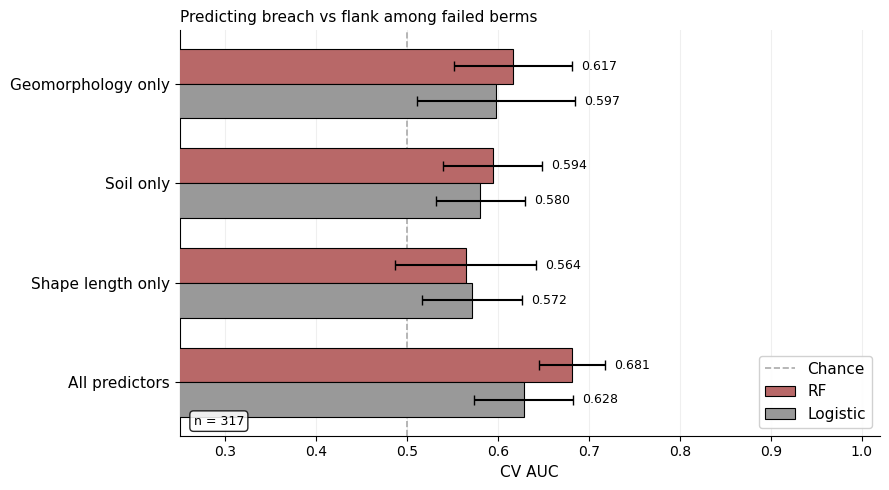

In [65]:
# ── Horizontal bar chart: breach prediction, scenario × model ─────────────────
_key_order_f = ['landscape_geomorphology_only', 'soil_only',
                'shape_length_only', 'all_predictors']
_label_map_f = {
    'landscape_geomorphology_only': 'Geomorphology only',
    'soil_only':                    'Soil only',
    'shape_length_only':            'Shape length only',
    'all_predictors':               'All predictors',
}

_FS = FS
fig_fail_model, ax_fm = plt.subplots(figsize=(9, 5))
_y_pos_f = np.arange(len(_key_order_f))
_w = 0.35

_clr_rf = BREACH_COL
_clr_lr = '#999999'

_rf_sub = _fail_baseline_df[_fail_baseline_df['model'] == 'RF'].set_index('scenario').reindex(_key_order_f)
_lr_sub = _fail_baseline_df[_fail_baseline_df['model'] == 'Logistic'].set_index('scenario').reindex(_key_order_f)

ax_fm.barh(_y_pos_f - _w/2, _rf_sub['cv_auc_mean'].values, _w,
           xerr=_rf_sub['cv_auc_sd'].values,
           color=_clr_rf, edgecolor='black', lw=0.8, capsize=3.5,
           label='RF', zorder=3)
ax_fm.barh(_y_pos_f + _w/2, _lr_sub['cv_auc_mean'].values, _w,
           xerr=_lr_sub['cv_auc_sd'].values,
           color=_clr_lr, edgecolor='black', lw=0.8, capsize=3.5,
           label='Logistic', zorder=3)

# Value labels
for i in range(len(_key_order_f)):
    ax_fm.text(_rf_sub['cv_auc_mean'].values[i] + _rf_sub['cv_auc_sd'].values[i] + 0.01,
               i - _w/2, f'{_rf_sub["cv_auc_mean"].values[i]:.3f}',
               ha='left', va='center', fontsize=_FS - 2)
    ax_fm.text(_lr_sub['cv_auc_mean'].values[i] + _lr_sub['cv_auc_sd'].values[i] + 0.01,
               i + _w/2, f'{_lr_sub["cv_auc_mean"].values[i]:.3f}',
               ha='left', va='center', fontsize=_FS - 2)

ax_fm.axvline(0.5, color=MODEL_CLR_CHANCE, ls='--', lw=1.2, label='Chance', zorder=0)
ax_fm.set_yticks(_y_pos_f)
ax_fm.set_yticklabels([_label_map_f[s] for s in _key_order_f], fontsize=_FS)
ax_fm.invert_yaxis()
ax_fm.set_xlim(0.25, 1.02)
ax_fm.set_xlabel('CV AUC', fontsize=_FS)
ax_fm.set_title('Predicting breach vs flank among failed berms',
                fontsize=_FS, fontweight='normal', loc='left')
ax_fm.legend(fontsize=_FS, loc='lower right', framealpha=0.9)
ax_fm.spines[['top', 'right']].set_visible(False)
ax_fm.grid(axis='x', alpha=0.2)
ax_fm.text(0.02, 0.02, f'n = {_fail_baseline_df["n"].iloc[0]}',
           transform=ax_fm.transAxes, fontsize=_FS - 2, va='bottom',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

## SI Table Exports

Export summary tables for the failure mechanisms paper supplementary information.

In [66]:
# ── SI Table 1: Chi-square summary for categorical predictors ─────────────────
_si_dir = _os.path.join(_fig_dir, 'si_tables')
_os.makedirs(_si_dir, exist_ok=True)

_chi2_summary = pd.DataFrame([
    {'Predictor': 'Texture (top 3)',      'χ²': _chi2_tex, 'dof': _dof_tex, 'p': _p_tex, "Cramér's V": _V_tex},
    {'Predictor': 'Landform',             'χ²': _chi2_lf,  'dof': _dof_lf,  'p': _p_lf,  "Cramér's V": _V_lf},
    {'Predictor': 'Berm_Length_Class',    'χ²': _chi2_len, 'dof': _dof_len, 'p': _p_len, "Cramér's V": _V_len},
    {'Predictor': 'Slope_Class',          'χ²': _chi2_sl,  'dof': _dof_sl,  'p': _p_sl,  "Cramér's V": _V_sl},
    {'Predictor': 'Soil_Development',     'χ²': _chi2_sd,  'dof': _dof_sd,  'p': _p_sd,  "Cramér's V": _V_sd},
    {'Predictor': 'High_Clay',            'χ²': _chi2_hc,  'dof': _dof_hc,  'p': _p_hc,  "Cramér's V": _V_hc},
])
_chi2_summary.to_csv(_os.path.join(_si_dir, 'SI_chi2_summary_failtype.csv'), index=False)
print('SI Table 1 — Chi-square summary:')
display(_chi2_summary.round(4))

# ── SI Table 2: Conditional failure-mode probabilities ────────────────────────
_cond_df.to_csv(_os.path.join(_si_dir, 'SI_conditional_probs_failtype.csv'), index=False)
print('\nSI Table 2 — Conditional probabilities saved.')

# ── SI Table 3: Kruskal-Wallis summary for continuous predictors ──────────────
_kw_rows = []
for _name, _res in [('|berm_angle|', _res_angle), ('log(FA_30_mean)', _res_fa),
                     ('saviD_60', _res_savi_d), ('saviU_60', _res_savi_u),
                     ('veg_effect', _res_veg_eff), ('road_dist', _res_road)]:
    if _res is None:
        continue
    _kw_rows.append({'Predictor': _name, 'H': _res['H'], 'p': _res['p_kw']})
_kw_summary = pd.DataFrame(_kw_rows)
_kw_summary.to_csv(_os.path.join(_si_dir, 'SI_kruskal_wallis_failtype.csv'), index=False)
print('\nSI Table 3 — Kruskal-Wallis summary:')
display(_kw_summary.round(4))

# ── SI Table 4: Within-landform interaction tests ─────────────────────────────
if '_int_df' in dir():
    _int_df.to_csv(_os.path.join(_si_dir, 'SI_interaction_landform_texture.csv'), index=False)
    print('\nSI Table 4 — Interaction tests saved.')

print(f'\nAll SI tables saved to: {_si_dir}/')

NameError: name '_chi2_len' is not defined